# LLM Classification Finetuning

Predicting which LLM response wins in a pairwise comparison (A wins / B wins / Tie).

## 1. Setup

Install packages, import all dependencies, and mount Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/llm-project', exist_ok=True)

SAVE_DIR = '/content/drive/MyDrive/llm-project'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save dir: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save dir: /content/drive/MyDrive/llm-project


In [2]:
!pip install -q transformers==4.45.2 datasets accelerate
!pip install -q sentencepiece protobuf
!pip install -q scikit-learn
!pip install -q pyarrow

# Verify version
import transformers
print(f"Transformers version: {transformers.__version__}")  # must be 4.45.2

Transformers version: 4.45.2


In [3]:
import torch
import transformers
import datasets
import pandas as pd

print(f"PyTorch:        {torch.__version__}")
print(f"Transformers:   {transformers.__version__}")
print(f"GPU available:  {torch.cuda.is_available()}")
print(f"GPU name:       {torch.cuda.get_device_name(0)}")

PyTorch:        2.10.0+cu128
Transformers:   4.45.2
GPU available:  True
GPU name:       NVIDIA A100-SXM4-80GB


In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
import torch

print(f"PyTorch: {torch.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


In [5]:
import torch

def get_gpu_config():
    if not torch.cuda.is_available():
        raise RuntimeError("No GPU detected — enable a GPU runtime in Colab.")
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    bf16_ok  = torch.cuda.is_bf16_supported()
    # MAX_LEN 1024 for high-VRAM GPUs: captures 85%+ of texts fully (vs 512 which truncated most)
    if vram_gb >= 48:
        max_len, batch, accum = 768, 16, 2   # effective batch=32
    elif vram_gb >= 32:
        max_len, batch, accum = 768, 16, 2   # effective batch=32
    elif vram_gb >= 20:
        max_len, batch, accum = 512, 8, 4    # effective batch=32
    elif vram_gb >= 14:
        max_len, batch, accum = 384, 4, 8    # effective batch=32
    else:
        max_len, batch, accum = 256, 2, 16   # effective batch=32
    use_bf16 = bf16_ok
    use_fp16 = not bf16_ok
    print(f"GPU:              {gpu_name}")
    print(f"VRAM:             {vram_gb:.1f} GB")
    print(f"Precision:        {'bf16' if use_bf16 else 'fp16'}")
    print(f"MAX_LEN:          {max_len}")
    print(f"Batch size:       {batch}  (x{accum} grad accum = {batch*accum} effective)")
    return max_len, batch, accum, use_bf16, use_fp16

MAX_LEN, BATCH_SIZE, GRAD_ACCUM, USE_BF16, USE_FP16 = get_gpu_config()

GPU:              NVIDIA A100-SXM4-80GB
VRAM:             85.1 GB
Precision:        bf16
MAX_LEN:          768
Batch size:       16  (x2 grad accum = 32 effective)


## 2. Load & Inspect Data

In [6]:
DATA_DIR = '/content/drive/MyDrive/llm-project/llm-classification-finetuning'

train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (57477, 9)
Test shape:  (3, 4)


In [7]:
print("Train columns:", list(train_df.columns))
print("Test columns: ", list(test_df.columns))
print(train_df.columns.tolist())

Train columns: ['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b', 'winner_model_a', 'winner_model_b', 'winner_tie']
Test columns:  ['id', 'prompt', 'response_a', 'response_b']
['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b', 'winner_model_a', 'winner_model_b', 'winner_tie']


In [8]:
sample = train_df.iloc[0]

print("=== PROMPT ===")
print(sample['prompt'][:300])

print("\n=== RESPONSE A ===")
print(sample['response_a'][:300])

print("\n=== RESPONSE B ===")
print(sample['response_b'][:300])

print("\n=== WINNER ===")
print(f"winner_model_a: {sample['winner_model_a']}")
print(f"winner_model_b: {sample['winner_model_b']}")
print(f"winner_tie:     {sample['winner_tie']}")   # ← fixed

=== PROMPT ===
["Is it morally right to try to have a certain percentage of females on managerial positions?","OK, does pineapple belong on a pizza? Relax and give me fun answer."]

=== RESPONSE A ===
["The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, diversity, and discrimination.\n\nHere are some arguments in favor of and against such policies:\n\n**Argume

=== RESPONSE B ===
["As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in managerial positions is a complex one and positions can vary. Advocates argue that such measures can help correct historical imbalances, promote diversity, and may lead to better deci

=== WINNER ===
winner_model_a: 1
winner_model_b: 0
winner_tie:     0


In [9]:
print("=== Missing Values in Train ===")
print(train_df.isnull().sum())

print("\n=== Missing Values in Test ===")
print(test_df.isnull().sum())

=== Missing Values in Train ===
id                0
model_a           0
model_b           0
prompt            0
response_a        0
response_b        0
winner_model_a    0
winner_model_b    0
winner_tie        0
dtype: int64

=== Missing Values in Test ===
id            0
prompt        0
response_a    0
response_b    0
dtype: int64


In [10]:
# Fill any nulls with empty string
train_df['prompt']     = train_df['prompt'].fillna('')
train_df['response_a'] = train_df['response_a'].fillna('')
train_df['response_b'] = train_df['response_b'].fillna('')

test_df['prompt']      = test_df['prompt'].fillna('')
test_df['response_a']  = test_df['response_a'].fillna('')
test_df['response_b']  = test_df['response_b'].fillna('')

## 3. Exploratory Data Analysis

=== Class Distribution ===
Model A wins: 20,064  (34.9%)
Model B wins: 19,652  (34.2%)
Ties:         17,761  (30.9%)


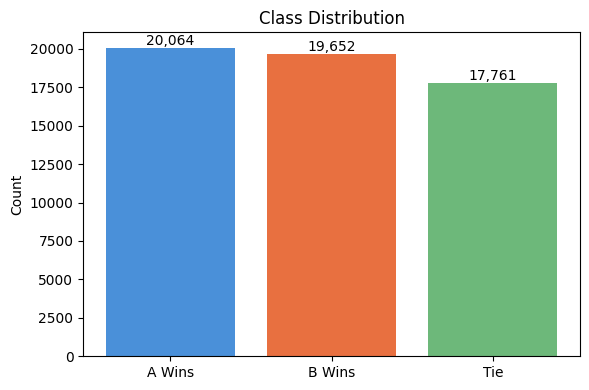

In [11]:
import matplotlib.pyplot as plt

a_wins = train_df['winner_model_a'].sum()
b_wins = train_df['winner_model_b'].sum()
ties   = train_df['winner_tie'].sum()              # ← fixed
total  = len(train_df)

print("=== Class Distribution ===")
print(f"Model A wins: {a_wins:,}  ({a_wins/total*100:.1f}%)")
print(f"Model B wins: {b_wins:,}  ({b_wins/total*100:.1f}%)")
print(f"Ties:         {ties:,}  ({ties/total*100:.1f}%)")

plt.figure(figsize=(6, 4))
plt.bar(['A Wins', 'B Wins', 'Tie'], [a_wins, b_wins, ties],
        color=['#4A90D9', '#E87040', '#6DB87A'])
plt.title('Class Distribution')
plt.ylabel('Count')
for i, v in enumerate([a_wins, b_wins, ties]):
    plt.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [12]:
# Calculate total combined length per row
train_df['prompt_len']     = train_df['prompt'].str.len()
train_df['response_a_len'] = train_df['response_a'].str.len()
train_df['response_b_len'] = train_df['response_b'].str.len()
train_df['total_len']      = (train_df['prompt_len'] +
                               train_df['response_a_len'] +
                               train_df['response_b_len'])

print("=== Text Length Stats (characters) ===")
print(train_df[['prompt_len', 'response_a_len', 'response_b_len', 'total_len']].describe().round(0))

=== Text Length Stats (characters) ===
       prompt_len  response_a_len  response_b_len  total_len
count     57477.0         57477.0         57477.0    57477.0
mean        369.0          1378.0          1386.0     3133.0
std        1073.0          1514.0          1538.0     3232.0
min           7.0             4.0             4.0       26.0
25%          52.0           408.0           413.0     1218.0
50%          96.0          1076.0          1086.0     2447.0
75%         243.0          1862.0          1873.0     3967.0
max       33056.0         54058.0         53830.0    76468.0


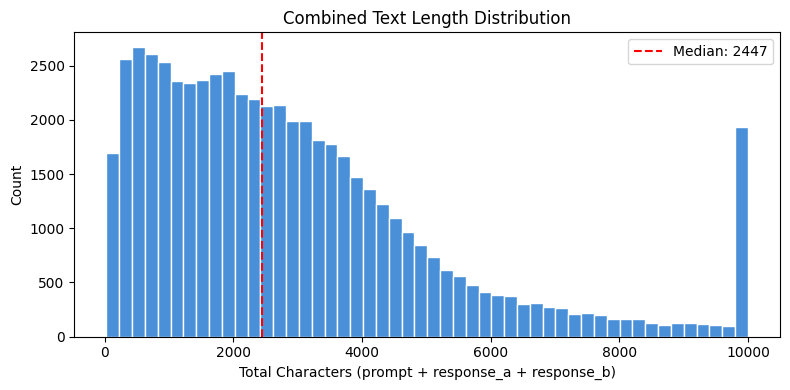


Rows under 2000 chars:  23,750 (41.3%)
Rows under 5000 chars:  48,865 (85.0%)
Rows under 10000 chars: 55,621 (96.8%)


In [13]:
plt.figure(figsize=(8, 4))
plt.hist(train_df['total_len'].clip(upper=10000), bins=50, color='#4A90D9', edgecolor='white')
plt.title('Combined Text Length Distribution')
plt.xlabel('Total Characters (prompt + response_a + response_b)')
plt.ylabel('Count')
plt.axvline(train_df['total_len'].median(), color='red',
            linestyle='--', label=f"Median: {train_df['total_len'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nRows under 2000 chars:  {(train_df['total_len'] < 2000).sum():,} ({(train_df['total_len'] < 2000).mean()*100:.1f}%)")
print(f"Rows under 5000 chars:  {(train_df['total_len'] < 5000).sum():,} ({(train_df['total_len'] < 5000).mean()*100:.1f}%)")
print(f"Rows under 10000 chars: {(train_df['total_len'] < 10000).sum():,} ({(train_df['total_len'] < 10000).mean()*100:.1f}%)")

In [14]:
print("========== EDA SUMMARY ==========")
print(f"Total training rows:    {len(train_df):,}")
print(f"Total test rows:        {len(test_df):,}")
print(f"Class A wins:           {a_wins/total*100:.1f}%")
print(f"Class B wins:           {b_wins/total*100:.1f}%")
print(f"Class Tie:              {ties/total*100:.1f}%")
print(f"Avg total text length:  {train_df['total_len'].mean():.0f} chars")
print(f"Median total length:    {train_df['total_len'].median():.0f} chars")
print(f"Missing values:         None (handled)")
print("=================================")

========== EDA SUMMARY ==========
Total training rows:    57,477
Total test rows:        3
Class A wins:           34.9%
Class B wins:           34.2%
Class Tie:              30.9%
Avg total text length:  3133 chars
Median total length:    2447 chars
Missing values:         None (handled)


## 4. Preprocessing

Convert binary winner columns to a single label, format input text, and split into train/val.

In [15]:
from sklearn.model_selection import train_test_split

# Convert 3 binary columns into single integer label
# 0 = A wins, 1 = B wins, 2 = tie
def get_label(row):
    if row['winner_model_a'] == 1: return 0
    if row['winner_model_b'] == 1: return 1
    return 2

train_df['label'] = train_df.apply(get_label, axis=1)

# Verify
print("Label distribution:")
print(train_df['label'].value_counts().sort_index())
print("\n0 = A wins, 1 = B wins, 2 = tie")

Label distribution:
label
0    20064
1    19652
2    17761
Name: count, dtype: int64

0 = A wins, 1 = B wins, 2 = tie


In [16]:
import json

def safe_json_to_text(value):
    """Parse JSON-encoded list of strings into plain text. Falls back to raw string."""
    try:
        parsed = json.loads(value)
        if isinstance(parsed, list):
            return ' '.join(str(turn).strip() for turn in parsed)
        return str(parsed).strip()
    except (json.JSONDecodeError, TypeError):
        return str(value).strip()

def format_input(row):
    prompt     = safe_json_to_text(row['prompt'])
    response_a = safe_json_to_text(row['response_a'])
    response_b = safe_json_to_text(row['response_b'])
    return f"[PROMPT] {prompt} [RESPONSE A] {response_a} [RESPONSE B] {response_b}"

train_df['text'] = train_df.apply(format_input, axis=1)
test_df['text']  = test_df.apply(format_input, axis=1)

# Verify the text is clean (no JSON brackets at start)
sample = train_df['text'].iloc[0]
assert not sample.startswith('[PROMPT] ["'), "JSON still not parsed!"
print("=== Sample Formatted Input (cleaned) ===")
print(sample[:400])
print(f"\nText column created for {len(train_df):,} train rows")
print(f"Text column created for {len(test_df):,} test rows")
print("Text formatting done!")

=== Sample Formatted Input (cleaned) ===
[PROMPT] Is it morally right to try to have a certain percentage of females on managerial positions? OK, does pineapple belong on a pizza? Relax and give me fun answer. [RESPONSE A] The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, diversity, and discriminatio

Text column created for 57,477 train rows
Text column created for 3 test rows
Text formatting done!


In [17]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.1,           # 10% for validation
    stratify=train_df['label'],  # keep class balance in both splits
    random_state=42
)

# Reset index
train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)

print(f"Training rows:   {len(train_data):,}")
print(f"Validation rows: {len(val_data):,}")

# Verify class balance is maintained in both splits
print("\nTrain label distribution:")
print(train_data['label'].value_counts().sort_index())
print("\nVal label distribution:")
print(val_data['label'].value_counts().sort_index())

Training rows:   51,729
Validation rows: 5,748

Train label distribution:
label
0    18057
1    17687
2    15985
Name: count, dtype: int64

Val label distribution:
label
0    2007
1    1965
2    1776
Name: count, dtype: int64


In [18]:
SAVE_DIR = '/content/drive/MyDrive/llm-project'

# Use parquet instead of CSV — handles embedded newlines and special chars in text safely
train_data.to_parquet(f'{SAVE_DIR}/train_processed.parquet', index=False)
val_data.to_parquet(f'{SAVE_DIR}/val_processed.parquet',   index=False)
test_df.to_parquet(f'{SAVE_DIR}/test_processed.parquet',   index=False)

print("Preprocessed data saved to Drive (parquet)!")
print(f"   {SAVE_DIR}/train_processed.parquet")
print(f"   {SAVE_DIR}/val_processed.parquet")
print(f"   {SAVE_DIR}/test_processed.parquet")

Preprocessed data saved to Drive (parquet)!
   /content/drive/MyDrive/llm-project/train_processed.parquet
   /content/drive/MyDrive/llm-project/val_processed.parquet
   /content/drive/MyDrive/llm-project/test_processed.parquet


In [19]:
print("========== PHASE 3 SUMMARY ==========")
print(f"Training rows:         {len(train_data):,}")
print(f"Validation rows:       {len(val_data):,}")
print(f"Test rows:             {len(test_df):,}")
print(f"Label mapping:         0=A wins, 1=B wins, 2=tie")
print(f"Input format:          [PROMPT] + [RESPONSE A] + [RESPONSE B]")
print(f"Sample text length:    {train_data['text'].str.len().median():.0f} chars (median)")
print(f"Class balance train:   {train_data['label'].value_counts(normalize=True).sort_index().to_dict()}")
print("=====================================")
print("✅ Phase 3 Complete! Ready for model loading.")

========== PHASE 3 SUMMARY ==========
Training rows:         51,729
Validation rows:       5,748
Test rows:             3
Label mapping:         0=A wins, 1=B wins, 2=tie
Input format:          [PROMPT] + [RESPONSE A] + [RESPONSE B]
Sample text length:    2396 chars (median)
Class balance train:   {0: 0.34906918749637533, 1: 0.34191652651317445, 2: 0.3090142859904502}
✅ Phase 3 Complete! Ready for model loading.


## 5. Tokenize & Build Datasets

In [20]:
MODEL_NAME = "microsoft/deberta-v3-large"
# MAX_LEN is set by get_gpu_config() above

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"MAX_LEN: {MAX_LEN}")
print(" Tokenizer loaded!")

Loading tokenizer: microsoft/deberta-v3-large


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:558: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


MAX_LEN: 768
 Tokenizer loaded!


In [21]:
sample_text = train_data['text'].iloc[0]

tokens = tokenizer(
    sample_text,
    truncation=True,
    max_length=MAX_LEN,
    return_tensors='pt'
)

print(f"Sample text length:    {len(sample_text)} chars")
print(f"Tokenized length:      {tokens['input_ids'].shape[1]} tokens")
print(f"Max length setting:    {MAX_LEN}")

# Check how much is being truncated
full_tokens = tokenizer(sample_text, truncation=False)
print(f"Full token count:      {len(full_tokens['input_ids'])} tokens")
print(f"Truncated:             {max(0, len(full_tokens['input_ids']) - MAX_LEN)} tokens cut off")
print("✅ Tokenizer working correctly!")

Sample text length:    1810 chars
Tokenized length:      364 tokens
Max length setting:    768
Full token count:      364 tokens
Truncated:             0 tokens cut off
✅ Tokenizer working correctly!


In [22]:
from datasets import Dataset

# Ensure labels are int64 — CrossEntropyLoss requires long, not int32
train_data['label'] = train_data['label'].astype('int64')
val_data['label']   = val_data['label'].astype('int64')

train_ds = Dataset.from_pandas(
    train_data[['text', 'label']].rename(columns={'label': 'labels'}).reset_index(drop=True)
)
val_ds = Dataset.from_pandas(
    val_data[['text', 'label']].rename(columns={'label': 'labels'}).reset_index(drop=True)
)
test_ds = Dataset.from_pandas(
    test_df[['text']].reset_index(drop=True)
)

print(f"Train dataset: {train_ds}")
print(f"Val dataset:   {val_ds}")
print(f"Test dataset:  {test_ds}")
print(f"Label dtype in pandas: {train_data['label'].dtype}")

Train dataset: Dataset({
    features: ['text', 'labels'],
    num_rows: 51729
})
Val dataset:   Dataset({
    features: ['text', 'labels'],
    num_rows: 5748
})
Test dataset:  Dataset({
    features: ['text'],
    num_rows: 3
})
Label dtype in pandas: int64


In [23]:
def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LEN,
        padding=False,
    )

print("Tokenizing train...")
train_ds = train_ds.map(tokenize, batched=True, batch_size=256, remove_columns=['text'])

print("Tokenizing validation...")
val_ds = val_ds.map(tokenize, batched=True, batch_size=256, remove_columns=['text'])

print("Tokenizing test...")
test_ds = test_ds.map(tokenize, batched=True, batch_size=256, remove_columns=['text'])

print("All datasets tokenized!")

Tokenizing train...


Map:   0%|          | 0/51729 [00:00<?, ? examples/s]

Tokenizing validation...


Map:   0%|          | 0/5748 [00:00<?, ? examples/s]

Tokenizing test...


Map:   0%|          | 0/3 [00:00<?, ? examples/s]

All datasets tokenized!


In [24]:
import torch

# Only include token_type_ids if the tokenizer actually produced them
sample_keys = list(train_ds[0].keys())
model_cols = [k for k in ['input_ids', 'attention_mask', 'token_type_ids'] if k in sample_keys]
print(f"Model columns: {model_cols}")

train_ds.set_format('torch', columns=model_cols + ['labels'])
val_ds.set_format('torch',   columns=model_cols + ['labels'])
test_ds.set_format('torch',  columns=model_cols)

sample = train_ds[0]
print("input_ids shape:      ", sample['input_ids'].shape)
print("attention_mask shape: ", sample['attention_mask'].shape)
print("label value:          ", sample['labels'].item())
print("label dtype:          ", sample['labels'].dtype)

# Catch dtype issues here before training starts
assert sample['labels'].dtype == torch.int64, \
    f"Label dtype is {sample['labels'].dtype} — must be int64 for CrossEntropyLoss!"
print("Label dtype OK — ready to train.")

Model columns: ['input_ids', 'attention_mask', 'token_type_ids']
input_ids shape:       torch.Size([364])
attention_mask shape:  torch.Size([364])
label value:           0
label dtype:           torch.int64
Label dtype OK — ready to train.


## 6. Load Model

In [25]:
import subprocess, os, gc, torch

def clean_gpu():
    print("=== GPU CLEANUP ===")
    cur_pid = os.getpid()

    # Kill every other process holding GPU memory
    try:
        result = subprocess.run(
            ['fuser', '/dev/nvidia0'],
            capture_output=True, text=True
        )
        pids = [int(p) for p in result.stdout.split() if p.strip().isdigit()]
        killed = []
        for pid in pids:
            if pid != cur_pid:
                try:
                    subprocess.run(['kill', '-9', str(pid)], check=True)
                    killed.append(pid)
                except Exception:
                    pass
        if killed:
            print(f"Killed stale GPU processes: {killed}")
        else:
            print("No stale GPU processes found.")
    except FileNotFoundError:
        print("fuser not available — skipping process kill.")

    # Only delete GPU-resident objects (model/trainer), NOT datasets
    for var in ['model', 'trainer']:
        if var in globals():
            del globals()[var]
            print(f"Cleared: {var}")

    # Clear Python memory and CUDA cache
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        free = (torch.cuda.get_device_properties(0).total_memory
                - torch.cuda.memory_allocated()) / 1e9
        print(f"GPU memory free after cleanup: {free:.1f} GB")
    print("=== CLEANUP DONE ===")

clean_gpu()

=== GPU CLEANUP ===
No stale GPU processes found.
GPU memory free after cleanup: 85.1 GB
=== CLEANUP DONE ===


In [26]:
import torch
import gc
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Clear any leftover GPU memory from previous runs
gc.collect()
torch.cuda.empty_cache()
print(f"GPU free before loading: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")

MODEL_NAME = "microsoft/deberta-v3-large"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True,
    torch_dtype=torch.float32,
)
model = model.cuda()

print(f"Model dtype:  {next(model.parameters()).dtype}")
print(f"Model device: {next(model.parameters()).device}")
print(f"GPU free after loading: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")
print("Model loaded!")

GPU free before loading: 85.1 GB


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:558: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model dtype:  torch.float32
Model device: cuda:0
GPU free after loading: 83.4 GB
Model loaded!


In [27]:
model = model.cuda()

# Check how much VRAM the model is using
vram_used  = torch.cuda.memory_allocated() / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free  = vram_total - vram_used

print(f"VRAM total: {vram_total:.1f} GB")
print(f"VRAM used:  {vram_used:.1f} GB  (model weights)")
print(f"VRAM free:  {vram_free:.1f} GB  (available for training)")

if vram_free > 10:
    print("✅ Plenty of VRAM free — training will run smoothly!")
elif vram_free > 5:
    print("⚠️ Moderate VRAM free — reduce batch size to 4 if you get OOM errors")
else:
    print("❌ Low VRAM — reduce MAX_LEN to 256 or batch size to 2")

VRAM total: 85.1 GB
VRAM used:  1.7 GB  (model weights)
VRAM free:  83.4 GB  (available for training)
✅ Plenty of VRAM free — training will run smoothly!


In [28]:
print("========== PHASE 4 SUMMARY ==========")
print(f"Model:             {MODEL_NAME}")
print(f"Max token length:  {MAX_LEN}")
print(f"Train batches:     {len(train_ds):,} rows")
print(f"Val batches:       {len(val_ds):,} rows")
print(f"Test batches:      {len(test_ds):,} rows")
print(f"VRAM used:         {torch.cuda.memory_allocated()/1e9:.1f} GB")
print(f"VRAM free:         {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1e9:.1f} GB")
print("=====================================")
print("✅ Phase 4 Complete! Ready to train.")

========== PHASE 4 SUMMARY ==========
Model:             microsoft/deberta-v3-large
Max token length:  768
Train batches:     51,729 rows
Val batches:       5,748 rows
Test batches:      3 rows
VRAM used:         1.7 GB
VRAM free:         83.4 GB
✅ Phase 4 Complete! Ready to train.


## 7. Training

Precision (bf16/fp16) and batch size are auto-configured by `get_gpu_config()` based on detected GPU/VRAM.
Uses `warmup_steps`, `evaluation_strategy="steps"`, and `DataCollatorWithPadding`.

In [29]:
import os
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback
from sklearn.metrics import log_loss
import numpy as np
import torch

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    logits = np.array(logits, dtype=np.float32)
    logits = np.nan_to_num(logits, nan=0.0, posinf=1.0, neginf=-1.0)
    e = np.exp(logits - logits.max(axis=-1, keepdims=True))
    probs = e / e.sum(axis=-1, keepdims=True)
    probs = np.clip(probs, 1e-7, 1 - 1e-7)
    return {"log_loss": log_loss(labels, probs)}

print("=== PRE-TRAINING CHECKS ===")
sample = train_ds[0]
assert sample['labels'].dtype == torch.int64, f"Labels are {sample['labels'].dtype}, need int64!"
print(f"[OK] Label dtype:   {sample['labels'].dtype}")
print(f"[OK] Input shape:   {sample['input_ids'].shape}")
print(f"[OK] Model dtype:   {next(model.parameters()).dtype}")
print(f"[OK] Model device:  {next(model.parameters()).device}")
print(f"[OK] BATCH_SIZE:    {BATCH_SIZE}  (x{GRAD_ACCUM} grad accum = {BATCH_SIZE * GRAD_ACCUM} effective)")
print(f"[OK] Precision:     {'bf16' if USE_BF16 else 'fp16'}")
print(f"[OK] MAX_LEN:       {MAX_LEN}")
print("=== ALL CHECKS PASSED - starting training ===")

EPOCHS = 3
steps_per_epoch = len(train_ds) // (BATCH_SIZE * GRAD_ACCUM)
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = int(total_steps * 0.1)
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")
print(f"Total steps: {total_steps:,}  |  Warmup steps: {warmup_steps:,}")

args = TrainingArguments(
    output_dir=f'{SAVE_DIR}/checkpoints',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=GRAD_ACCUM,

    learning_rate=2e-5,
    warmup_steps=warmup_steps,
    weight_decay=0.01,
    max_grad_norm=1.0,
    adam_epsilon=1e-6,
    label_smoothing_factor=0.1,

    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=3,

    load_best_model_at_end=True,
    metric_for_best_model="log_loss",
    greater_is_better=False,

    fp16=USE_FP16,
    bf16=USE_BF16,

    dataloader_num_workers=2,
    logging_steps=20,
    report_to="none",
)

data_collator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of=8)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

print("Starting training...")
trainer.train()

model.save_pretrained(f'{SAVE_DIR}/final_model')
tokenizer.save_pretrained(f'{SAVE_DIR}/final_model')
print("Done! Model saved.")

=== PRE-TRAINING CHECKS ===
[OK] Label dtype:   torch.int64
[OK] Input shape:   torch.Size([364])
[OK] Model dtype:   torch.float32
[OK] Model device:  cuda:0
[OK] BATCH_SIZE:    16  (x2 grad accum = 32 effective)
[OK] Precision:     bf16
[OK] MAX_LEN:       768
=== ALL CHECKS PASSED - starting training ===
Effective batch size: 32
Total steps: 4,848  |  Warmup steps: 484
Starting training...


Step,Training Loss,Validation Loss,Log Loss,Runtime,Samples Per Second,Steps Per Second
200,1.096300,1.092325,1.091277,115.249400,49.874000,3.124000
400,1.098900,1.087834,1.085305,115.251500,49.874000,3.124000
600,1.083800,1.083644,1.079441,115.213500,49.890000,3.125000
800,1.091600,1.084086,1.080984,115.210400,49.891000,3.125000
1000,1.093000,1.081852,1.077537,115.245400,49.876000,3.124000
1200,1.087200,1.075771,1.070855,115.375100,49.820000,3.120000
1400,1.087000,1.077725,1.073123,115.338300,49.836000,3.121000
1600,1.060500,1.064064,1.054823,115.255600,49.872000,3.123000
1800,1.036300,1.062630,1.045609,115.293000,49.856000,3.122000
2000,1.034800,1.042835,1.026265,115.342900,49.834000,3.121000


Done! Model saved.


In [34]:
import numpy as np
import pandas as pd

print("Generating predictions on test set...")
predictions = trainer.predict(test_ds)
logits = predictions.predictions.astype(np.float32)  # shape: (n_test, 3)

# Softmax to convert logits to probabilities
e = np.exp(logits - logits.max(axis=-1, keepdims=True))
probs = e / e.sum(axis=-1, keepdims=True)  # columns: [p_a_wins, p_b_wins, p_tie]

# Load original test IDs
test_ids = pd.read_csv(f'{DATA_DIR}/test.csv')['id']

submission = pd.DataFrame({
    'id':            test_ids.values,
    'winner_model_a': probs[:, 0],
    'winner_model_b': probs[:, 1],
    'winner_tie':     probs[:, 2],
})

submission.to_csv(f'{SAVE_DIR}/submission.csv', index=False)
print(f"Submission saved to {SAVE_DIR}/submission.csv")
print(submission)

Generating predictions on test set...


Submission saved to /content/drive/MyDrive/llm-project/submission.csv
        id  winner_model_a  winner_model_b  winner_tie
0   136060        0.153905        0.695166    0.150929
1   211333        0.192439        0.437710    0.369851
2  1233961        0.281007        0.309230    0.409763


## 8. Results & Diagnostics

In [35]:
print("=== Training History ===")
eval_logs = [log for log in trainer.state.log_history if 'eval_log_loss' in log]

if not eval_logs:
    print("No evaluation checkpoints yet (training did not reach an eval_steps boundary).")
    print("Training loss logs so far:")
    for log in trainer.state.log_history:
        if 'loss' in log:
            print(f"  Step {log.get('step', '?')} | Train Loss: {log['loss']:.4f}")
else:
    for log in eval_logs:
        print(f"Step {log.get('step','?')} (Epoch {log['epoch']:.2f}) | "
              f"Val Log Loss: {log['eval_log_loss']:.4f}")
    best_score = min(log['eval_log_loss'] for log in eval_logs)
    print(f"\nBest Val Log Loss: {best_score:.4f}")
    print("Best model loaded: yes (load_best_model_at_end=True)")

=== Training History ===
Step 200 (Epoch 0.12) | Val Log Loss: 1.0913
Step 400 (Epoch 0.25) | Val Log Loss: 1.0853
Step 600 (Epoch 0.37) | Val Log Loss: 1.0794
Step 800 (Epoch 0.49) | Val Log Loss: 1.0810
Step 1000 (Epoch 0.62) | Val Log Loss: 1.0775
Step 1200 (Epoch 0.74) | Val Log Loss: 1.0709
Step 1400 (Epoch 0.87) | Val Log Loss: 1.0731
Step 1600 (Epoch 0.99) | Val Log Loss: 1.0548
Step 1800 (Epoch 1.11) | Val Log Loss: 1.0456
Step 2000 (Epoch 1.24) | Val Log Loss: 1.0263
Step 2200 (Epoch 1.36) | Val Log Loss: 1.0119
Step 2400 (Epoch 1.48) | Val Log Loss: 1.0127
Step 2600 (Epoch 1.61) | Val Log Loss: 1.0044
Step 2800 (Epoch 1.73) | Val Log Loss: 1.0117
Step 3000 (Epoch 1.86) | Val Log Loss: 0.9970
Step 3200 (Epoch 1.98) | Val Log Loss: 0.9925
Step 3400 (Epoch 2.10) | Val Log Loss: 1.0000
Step 3600 (Epoch 2.23) | Val Log Loss: 1.0174
Step 3800 (Epoch 2.35) | Val Log Loss: 1.0130
Step 4000 (Epoch 2.47) | Val Log Loss: 1.0173
Step 4200 (Epoch 2.60) | Val Log Loss: 1.0112

Best Val Log

In [36]:
print("=== Training History ===")
eval_logs = [log for log in trainer.state.log_history if 'eval_log_loss' in log]

if not eval_logs:
    print("No evaluation logs found.")
else:
    for log in eval_logs:
        print(f"Step {log.get('step','?')} (Epoch {log['epoch']:.2f}) | Val Log Loss: {log['eval_log_loss']:.4f}")
    best_score = min(log['eval_log_loss'] for log in eval_logs)
    print(f"Best Val Log Loss: {best_score:.4f}")
    print(f"Total steps:       {trainer.state.global_step:,}")
    print(f"Epochs trained:    {trainer.state.epoch:.2f}")

=== Training History ===
Step 200 (Epoch 0.12) | Val Log Loss: 1.0913
Step 400 (Epoch 0.25) | Val Log Loss: 1.0853
Step 600 (Epoch 0.37) | Val Log Loss: 1.0794
Step 800 (Epoch 0.49) | Val Log Loss: 1.0810
Step 1000 (Epoch 0.62) | Val Log Loss: 1.0775
Step 1200 (Epoch 0.74) | Val Log Loss: 1.0709
Step 1400 (Epoch 0.87) | Val Log Loss: 1.0731
Step 1600 (Epoch 0.99) | Val Log Loss: 1.0548
Step 1800 (Epoch 1.11) | Val Log Loss: 1.0456
Step 2000 (Epoch 1.24) | Val Log Loss: 1.0263
Step 2200 (Epoch 1.36) | Val Log Loss: 1.0119
Step 2400 (Epoch 1.48) | Val Log Loss: 1.0127
Step 2600 (Epoch 1.61) | Val Log Loss: 1.0044
Step 2800 (Epoch 1.73) | Val Log Loss: 1.0117
Step 3000 (Epoch 1.86) | Val Log Loss: 0.9970
Step 3200 (Epoch 1.98) | Val Log Loss: 0.9925
Step 3400 (Epoch 2.10) | Val Log Loss: 1.0000
Step 3600 (Epoch 2.23) | Val Log Loss: 1.0174
Step 3800 (Epoch 2.35) | Val Log Loss: 1.0130
Step 4000 (Epoch 2.47) | Val Log Loss: 1.0173
Step 4200 (Epoch 2.60) | Val Log Loss: 1.0112
Best Val Log 

In [33]:
print("=== Training History ===")
eval_logs = [log for log in trainer.state.log_history if 'eval_log_loss' in log]

if not eval_logs:
    print("No evaluation logs found.")
else:
    for log in eval_logs:
        print(f"Step {log.get('step','?')} (Epoch {log['epoch']:.2f}) | Val Log Loss: {log['eval_log_loss']:.4f}")
    best_score = min(log['eval_log_loss'] for log in eval_logs)
    print(f"Best Val Log Loss: {best_score:.4f}")
    print(f"Total steps:       {trainer.state.global_step:,}")
    print(f"Epochs trained:    {trainer.state.epoch:.2f}")

=== Training History ===
Step 200 (Epoch 0.12) | Val Log Loss: 1.0913
Step 400 (Epoch 0.25) | Val Log Loss: 1.0853
Step 600 (Epoch 0.37) | Val Log Loss: 1.0794
Step 800 (Epoch 0.49) | Val Log Loss: 1.0810
Step 1000 (Epoch 0.62) | Val Log Loss: 1.0775
Step 1200 (Epoch 0.74) | Val Log Loss: 1.0709
Step 1400 (Epoch 0.87) | Val Log Loss: 1.0731
Step 1600 (Epoch 0.99) | Val Log Loss: 1.0548
Step 1800 (Epoch 1.11) | Val Log Loss: 1.0456
Step 2000 (Epoch 1.24) | Val Log Loss: 1.0263
Step 2200 (Epoch 1.36) | Val Log Loss: 1.0119
Step 2400 (Epoch 1.48) | Val Log Loss: 1.0127
Step 2600 (Epoch 1.61) | Val Log Loss: 1.0044
Step 2800 (Epoch 1.73) | Val Log Loss: 1.0117
Step 3000 (Epoch 1.86) | Val Log Loss: 0.9970
Step 3200 (Epoch 1.98) | Val Log Loss: 0.9925
Step 3400 (Epoch 2.10) | Val Log Loss: 1.0000
Step 3600 (Epoch 2.23) | Val Log Loss: 1.0174
Step 3800 (Epoch 2.35) | Val Log Loss: 1.0130
Step 4000 (Epoch 2.47) | Val Log Loss: 1.0173
Step 4200 (Epoch 2.60) | Val Log Loss: 1.0112
Best Val Log 